# Addressing Class Imbalance 

Before we train any classification model, is there something that we have failed to address about our target variable? As a professional trainer, we cannot omit the one of most important steps of the data analytics life cycle - Data Exploration and Cleaning!
What does our target variable's distribution look like? Are they balance? Is one class represented to a lesser degree? 

The distribution of classess in a dataset matters in the training process and affects the performance of our predictive models. When faced with imbalanced classes, traditional machine learning algorithms can exhibit biased performance, often favoring the majority class.

In this notebook, we are going to introduce a few methods to address class imbalance. Then, we are going to train our decision tree classifer and see if we could improve the performance! 


## Outline <a name="top"></a>
1. [Class Imbalance](#imbalance)
2. [House Price Data Preparation](#cleaning)
    1. [Stratification](#strat)
    2. [AUC-ROC curve](#auc)
    3. [F1 Score](#f1)
    3. [Cohen's Kappa](#ck)
3. [Resampling methods](#resampling)
    1. [OverSampling](#oversampling)
    2. [UnderSampling](#undersampling)
    3. [SMOTE](#smote)
6. [Activity](#activity)

## Class Imbalance 

Class Imbalance refers to when observation in one class is higher than in other classes. Training procedures of standard classification algorithms are biased towards the majority class, as they strive to maximise classification accuracy or minimise error. If the dataframe has imbalanced classes, we get a pretty high accuracy just by predicting the majority class, but we fail to capture the minority class, which is most often the point of creating the model in the first place. 
It is common for classification problems to be imbalanced, with some of the most significant coming from application areas such as biomedicine, finance, information technology, industrial production, and security management. In most cases, it is crucial to recognise the minority class instance. 

In [1]:

#!pip install imblearn


In [2]:
### loading packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# For missing values imputation
from sklearn.impute import SimpleImputer

# For resampling our data
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# For Optimization (hyperparameter tuning)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV

# For ensemble algorithms (classification)
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve, roc_auc_score

# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")

## Data Preparation <a name="cleaning"></a>

We will be using the London House Price data for this class imbalance demonstration. 

Cleaning process would include removing unnecessary columns, checking values format, any duplicates, inconsistent formats and missing values etc. We also want to explore our data a bit more by looking into the distribution of our target variable. 


In [3]:
## Read in comma separated file 

df = pd.read_csv('./london_house_price_data.csv',index_col = [0])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1468 entries, 0 to 1467
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   link                  1468 non-null   object 
 1   saleprice             1379 non-null   float64
 2   address               1379 non-null   object 
 3   description           1468 non-null   object 
 4   added_date            1371 non-null   object 
 5   agent                 1468 non-null   object 
 6   property_type         1468 non-null   object 
 7   bedrooms              1468 non-null   int64  
 8   bathrooms             1468 non-null   int64  
 9   distance_to_station   1379 non-null   object 
 10  tenure                1254 non-null   object 
 11  leasehold_years_left  86 non-null     float64
 12  postcode              1021 non-null   object 
 13  borough               1021 non-null   object 
 14  crime_rate            1021 non-null   float64
 15  total_area            1379

In [4]:
def clean(df):
    ## Removing columns 
    byebye_col = ['link','address','description','added_date','sold_date','agent','postcode', 'borough']
    df = df.drop(columns = byebye_col)
    
    # Remove word "miles" in column "distance_to_station"
    df['distance_to_station'] = df['distance_to_station'].str.replace(' miles', '').astype('float')
    
    # Remove column leasehold_years_left
    df = df.drop('leasehold_years_left', axis = 1)
    
    # Dropping rows with target variable missing
    df.dropna(subset=['sold_under_90days'], inplace=True)
    df['sold_under_90days'] = df['sold_under_90days'].astype(int)
    
    return df

In [5]:
df = clean(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1379 entries, 0 to 1467
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   saleprice            1379 non-null   float64
 1   property_type        1379 non-null   object 
 2   bedrooms             1379 non-null   int64  
 3   bathrooms            1379 non-null   int64  
 4   distance_to_station  1379 non-null   float64
 5   tenure               1188 non-null   object 
 6   crime_rate           1021 non-null   float64
 7   total_area           1379 non-null   float64
 8   year_built           1379 non-null   int64  
 9   property_condition   1379 non-null   float64
 10  amenities_rating     1379 non-null   float64
 11  garden               1379 non-null   bool   
 12  balcony              1379 non-null   bool   
 13  fuel_type            1379 non-null   object 
 14  sold_under_90days    1379 non-null   int64  
dtypes: bool(2), float64(6), int64(4), object(3)

#### Function for missing value imputation

In [6]:
## Impute missing values using Simple Imputation method - let's impute our numerical values with 'mean' value and the categorical with 'most_frequent'
### Since we need to impute on both X_train and X_test separately, let's use a function to avoid repeating ourselves!!

def impute_missing_values(df):
    # Separate numerical and categorical features
    num_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    cat_features = df.select_dtypes(include=['object',"string","bool"]).columns.tolist()

    # Create separate SimpleImputer instances for numerical and categorical features
    num_imputer = SimpleImputer(strategy='mean')
    cat_imputer = SimpleImputer(strategy='most_frequent')

    # Impute missing values in numerical features
    df_num = df[num_features]
    df_num_imputed = num_imputer.fit_transform(df_num)

    # Convert the imputed numerical features back to a DataFrame
    df_num_imputed_df = pd.DataFrame(df_num_imputed, columns=num_features)

    # Impute missing values in categorical features
    df_cat = df[cat_features]
    df_cat_imputed = cat_imputer.fit_transform(df_cat)

    # Convert the imputed categorical features back to a DataFrame
    df_cat_imputed_df = pd.DataFrame(df_cat_imputed, columns=cat_features)

    # Combine the numerical and categorical DataFrames back into one DataFrame
    df_imputed = pd.concat([df_num_imputed_df, df_cat_imputed_df], axis=1)
    
    return df_imputed

#### Function for printing performance metric

In [7]:
# Let's have another function that allows you to print the performance metric for each class balancing method 

def get_results(truth, prediction, df, idx):

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probs)
    kappa = cohen_kappa_score(y_test, y_pred)

    df.loc[idx,:] = [acc, f1, precision, recall, auc, kappa]

    return df

### Assess the Degree of Imbalance 

In [8]:
# Calculate the minority class percentage 
min(df.sold_under_90days.value_counts()/len(df))
#It's a mild to moderate imbalance

0.26468455402465557

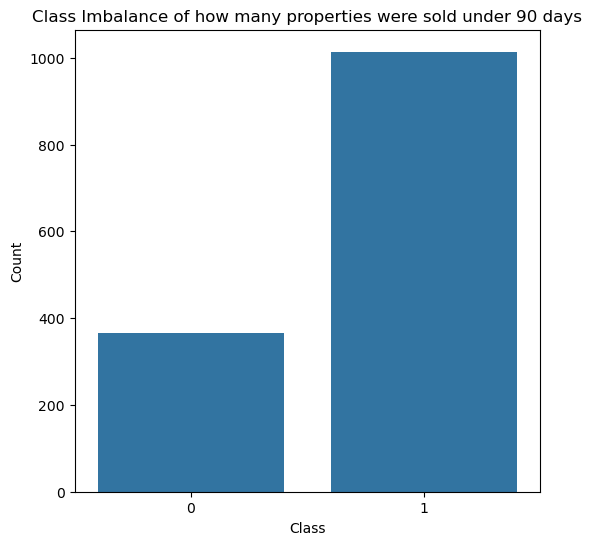

In [9]:
# You can also plot a graph to view 
plt.figure(figsize=(6,6))
sns.barplot(x=df['sold_under_90days'].value_counts().index, y=df['sold_under_90days'].value_counts().values)
plt.title('Class Imbalance of how many properties were sold under 90 days')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## More Evaluation metrics for classfication models
### AUC-ROC curve <a name="auc"></a>

A **receiver operating characteristic curve (ROC curve)** is another useful tool for evaluating classification models. The ROC curve is a graphical representation of a binary classifier's performance as the decision threshold is varied. By default, the threshold for predicting a label is 0.5, but it doesn't have to be. It is created by plotting the True Positive Rate (Sensitivity/Recall) on the y-axis against the False Positive Rate (1 - Specificity) on the x-axis at various threshold values. Each point on the curve represents the trade-off between the true positive rate and the false positive rate at a particular threshold. A ROC curve will for every threshold between 0 and 1 compare the true positive rate and true negative rate. 

You have already learnt the true positive rate- it is the recall. The false positive rate is the recall for the negative label.

\begin{equation*}
FPR = {FP}/ {FP+TN}
\end{equation*}

It illustrates how well the model separates the positive and negative samples as the decision threshold changes. A good classifier will have an ROC curve that rises steeply towards the top-left corner, indicating high true positive rates and low false positive rates for various threshold values.
When you plot these metrics against each other you get a curve, the further this curve stretches into the top right of the visualisation, the better your model is at prediction. If it forms a diagonal line it is not good for prediction at all.

The **AUC** is a single scalar value that summarizes the overall performance of the classifier across all possible decision thresholds. It represents the area under the ROC curve and ranges between 0 and 1.

- AUC = 0.5: If the AUC is 0.5, it means the model's performance is equivalent to random chance. This is because the ROC curve coincides with the diagonal line (the line of no-discrimination), which represents a random classifier.

- AUC > 0.5: An AUC greater than 0.5 indicates better-than-random performance. The closer the AUC is to 1, the better the classifier's ability to distinguish between positive and negative samples.

- AUC = 1: A perfect classifier has an AUC of 1, which means it achieves perfect separation between positive and negative samples for all decision thresholds.

<img src="auc-roc curve.png" width="450" align="center">

### F1 Score <a name="f1"></a>

F1 Score uses a harmonic mean in place of an arithmetic mean by slightly punishing the extreme values more and is also useful in situations where the data might be imbalanced. A model that can have a high accuracy by predicting the majority class all of the time could have a relatively low F1 score. 

The F1 score equation is : 

<img src="f1-score.png" width="450" align="center">

### Cohen's Kappa <a name="ck"></a>

Cohen's Kappa takes into account the level of agreement between raters beyond what would be expected by chance alone. It measures the degree of agreement while considering the possibility of random agreement. The value of Kappa can range from -1 to 1:

- Kappa = -1: Perfect disagreement beyond what would be expected by chance.
- Kappa < 0: Agreement is less than what would be expected by chance.
- Kappa = 0: Agreement is equal to what would be expected by chance.
- Kappa > 0: Agreement is greater than what would be expected by chance.
- Kappa = 1: Perfect agreement beyond what would be expected by chance.

A Kappa value of 0 means that the observed agreement is equal to the agreement expected by chance, indicating no better than random agreement. A Kappa value greater than 0 indicates that the observed agreement is better than random, while a negative Kappa value suggests less agreement than expected by chance.

Cohen's Kappa is often used when evaluating the performance of classification models, especially in cases where the class distribution is imbalanced. It helps account for the effect of chance agreement and provides a more reliable measure of agreement or performance between different raters or classifiers. A higher Kappa value indicates better agreement or classification performance.

## Baseline Decision Tree model without addressing class imbalance

In [10]:
### Building a baseline Decision Tree model without address class imbalance 
# extract the target
X = df.drop(columns = ['sold_under_90days'])
y = df['sold_under_90days']

# Train Test Split without stratification on target variable 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=456)

# Missing data Imputation
X_train_imputed = impute_missing_values(X_train)
X_test_imputed = impute_missing_values(X_test)

# One-Hot Encoding to convert categorical variables to numerical representations (before training the model)

X_train_encoded = pd.get_dummies(X_train_imputed, columns=['property_type','tenure','fuel_type'])
X_test_encoded = pd.get_dummies(X_test_imputed, columns=['property_type', 'tenure','fuel_type'])

dtDict = {    'max_depth': [5,10,25],
              'min_samples_split': [2,4,6],
              'min_samples_leaf': [1,2,4]} 

dt = DecisionTreeClassifier(random_state = 423)
dt_class = GridSearchCV(
    dt,
    param_grid=dtDict,
    scoring='accuracy',
    cv=3,
    verbose=1,
)

dt_class.fit(X_train_encoded, y_train) 
dt_best_params = dt_class.best_params_
dt_model = dt_class.best_estimator_
y_pred = dt_model.predict(X_test_encoded)

print("Best parameters:", dt_class.best_params_)
train_predictions = dt_model.predict(X_train_encoded)
print("Training Accuracy: ",accuracy_score(train_predictions, y_train))
print("Testing Accuracy: ",accuracy_score(y_pred, y_test))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Training Accuracy:  0.9011786038077969
Testing Accuracy:  0.894927536231884


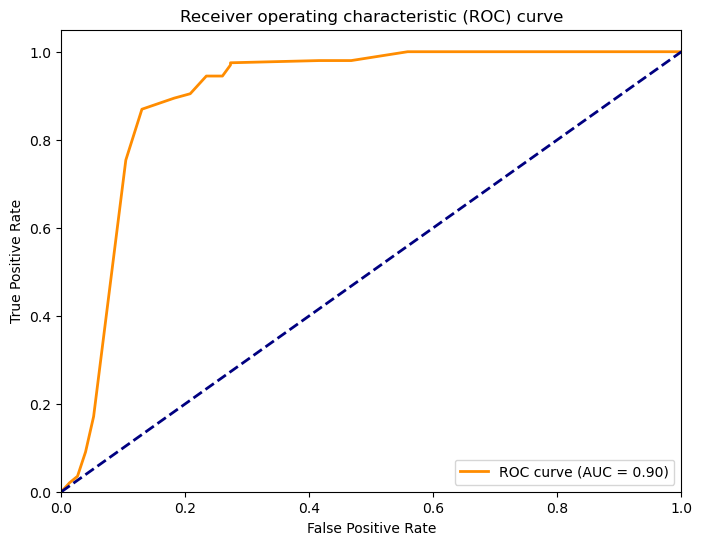

AUC score: 0.9003458852705084


In [11]:
# Plotting an AUC-ROC Curve graph 
from sklearn.metrics import roc_curve, auc

y_probs = dt_model.predict_proba(X_test_encoded)[:, 1]  # Probability estimates of the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.show()

print('AUC score:', roc_auc)

In [12]:
## Set up results df

results = pd.DataFrame(index = ['Baseline','Stratification only', 'Oversampling', 'Undersampling','SMOTE'], 
                       columns = ['accuracy', 'f1', 'precision', 'recall','auc','kappa']) #F1 is the harmonic mean of precision and recall.

# Use our function to get results 
results = get_results(y_test, y_pred, results, 'Baseline')
results

,accuracy,f1,precision,recall,auc,kappa
Baseline,0.894928,0.928395,0.912621,0.944724,0.900346,0.731337
Stratification only,NaN,NaN,NaN,NaN,NaN,NaN
Oversampling,NaN,NaN,NaN,NaN,NaN,NaN
Undersampling,NaN,NaN,NaN,NaN,NaN,NaN
SMOTE,NaN,NaN,NaN,NaN,NaN,NaN


### Stratification <a name="strat"></a>

Stratification means we are dividing our dataset into subsets (often during train-test-split/ cross-validation) in a way that each subset *maintains the same class distribution as the original dataset*. In other words, the proportion of each class in each subset is preserved, which can help prevent the majority class from dominating the learning process.

**Note : this method does NOT change the data itself but rather to ensure that the train and test sets follow the same distribution as our original dataset.**

Rather than using the default train_test_split provided by scikit-learn, we should try to make sure our splits accurately represent the distribution of our target variable. A very simple way to do this is to use the *stratify parameter* when calling the train_test_split function.

In [13]:
# Train Test Split with stratification on target variable 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=456, stratify=y)

# Missing data Imputation
X_train_imputed = impute_missing_values(X_train)
X_test_imputed = impute_missing_values(X_test)

# One-Hot Encoding to convert categorical variables to numerical representations (before training the model)

X_train_encoded = pd.get_dummies(X_train_imputed, columns=['property_type','tenure','fuel_type'])
X_test_encoded = pd.get_dummies(X_test_imputed, columns=['property_type', 'tenure','fuel_type'])

dt_class.fit(X_train_encoded, y_train) 
dt_model = dt_class.best_estimator_
y_pred = dt_model.predict(X_test_encoded)

print("Best parameters:", dt_class.best_params_)
train_predictions = dt_model.predict(X_train_encoded)
print("Training Accuracy: ",accuracy_score(train_predictions, y_train))
print("Testing Accuracy: ",accuracy_score(y_pred, y_test))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 4}
Training Accuracy:  0.9646418857660924
Testing Accuracy:  0.8405797101449275


In [14]:
# Use our function to get results 
results = get_results(y_test, y_pred, results, 'Stratification only')
results

,accuracy,f1,precision,recall,auc,kappa
Baseline,0.894928,0.928395,0.912621,0.944724,0.900346,0.731337
Stratification only,0.84058,0.89,0.903553,0.876847,0.435589,0.600763
Oversampling,NaN,NaN,NaN,NaN,NaN,NaN
Undersampling,NaN,NaN,NaN,NaN,NaN,NaN
SMOTE,NaN,NaN,NaN,NaN,NaN,NaN


It seems that both precision and recall has reduced after stratification, can you think of WHY it might happen?

<details>
<summary>Click to see some potential reasons </summary>

If the original dataset has a class imbalance, the model might have been biased towards the majority class, leading to a high precision for the majority class (due to correct predictions of majority class samples), but a poor recall for the minority class (due to missed predictions of minority class samples). After stratification, the training dataset becomes more balanced, allowing the model to learn from both classes more effectively. This could then cause the precision of the majority class to decrease as the model becomes more cautious in making positive predictions for the majority class. 

</details> 



## Resampling methods <a name="resampling"></a>

### Oversampling - duplicating <a name="oversampling"></a>
Oversampling is when we duplicate samples from the **minority** class. We want to balance the data set by increasing the size of the minority class to match the size of the majority class – this way, our classes are equal.

<img src="duplicating.png" width="450" align="center">

**Pros**
 - Does not decrease size of dataset 
 - Does not lose any information 
 - Can handle complex models 
 
**Cons**
- Can increase chance of overfitting: as it creates additional samples by duplicating minority class samples, they are identical to existing samples, providing redundatn information to the model. When a model sees the same samples multiple times during training, it can become overconfident in its ability to classify them correctly. Something SMOTE can overcome...
- May increase training time (depends on your dataset size...)

### Unsampling - deleting <a name="undersampling"></a>

Undersampling is when we delete samples from the **majority** class. We want to balance the data set by decreasing the size of the majority class to match the size of the minority class – this way, our classes are equal.

<img src="deleting.png" width="450" align="center">

Both oversampling and undersampling involve introducing a bias to select more samples from one class than from another, to compensate for an imbalance that is either already present in the data, or likely to develop if a purely random sample were taken.

**Pros**
- Does not introduce redundant information to dataset
- Reduces training time

**Cons** 
- Reduces size of dataset
- Loss of information 

### SMOTE - Synthetic Minority Oversampling Technique <a name="smote"></a>

SMOTE is a one of the most common oversampling technique. The algorithm generates synthetic samples for the minority class by creating new synthetic data points.

This is how a round of SMOTE works:

- Step 1: Choose any random datapoint (i.e., a row) in the Minority Class as a starting point.
- Step 2: Find the 5 nearest neighbours of that datapoint, considering all other variables.
- Step 3: Pick a random one of those five nearest neighbours.
- Step 4: Compute a synthetic datapoint the average of the neighbour and the datapoint in terms of each variable. This might be a bit whacky for any variable that is not numeric - but that is why SMOTE is generally only recommended to be used on numeric variables (although it does "work" with non-numeric variables too... just not as well).
- Step 5: Add that synthetic datapoint to the entire dataset, so it can be drawn as either a starting point or a neighbour in the next round.

This process will be repeated for as many rounds, until the desired ratio of minority and majority cases is reached.


<img src="smote.png" width="450" align="center">

There is a *imbalanced-learn* framework which was initiated in 2014 with the main focus being on **SMOTE (another technique for imbalanced data) implementation**. Here is a link to [Imbalanced-Learn](https://imbalanced-learn.org/stable/over_sampling.html) for guides on installation and the full documentation. For those who can pip install new library please do so! 

In [15]:
#!pip install imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

### Oversampling with decision tree! 

In [16]:
# Oversample with imblearn
ros = RandomOverSampler(random_state=123)
X_train_OverSampled, y_train_OverSampled = ros.fit_resample(X_train_encoded, y_train)  

In [17]:
#let's check our classes
y_train_OverSampled.value_counts()

sold_under_90days
1    811
0    811
Name: count, dtype: int64

In [18]:
dt_class.fit(X_train_OverSampled, y_train_OverSampled) 
dt_model = dt_class.best_estimator_
y_pred = dt_model.predict(X_test_encoded)
y_probs = dt_model.predict_proba(X_test_encoded)[:, 1]  # Probability estimates of the positive class

# Use our function to get results 
results = get_results(y_test, y_pred, results, 'Oversampling')
results

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,accuracy,f1,precision,recall,auc,kappa
Baseline,0.894928,0.928395,0.912621,0.944724,0.900346,0.731337
Stratification only,0.84058,0.89,0.903553,0.876847,0.435589,0.600763
Oversampling,0.855072,0.901961,0.897561,0.906404,0.809366,0.624209
Undersampling,NaN,NaN,NaN,NaN,NaN,NaN
SMOTE,NaN,NaN,NaN,NaN,NaN,NaN


### Undersampling with decision tree

In [19]:
# Undersample with imblearn
rus = RandomUnderSampler(random_state=123)
X_train_UnderSampled, y_train_UnderSampled = rus.fit_resample(X_train_encoded, y_train)  

In [20]:
#let's check our classes
y_train_UnderSampled.value_counts()

sold_under_90days
0    292
1    292
Name: count, dtype: int64

In [21]:
dt_class.fit(X_train_UnderSampled, y_train_UnderSampled) 
dt_model = dt_class.best_estimator_
y_pred = dt_model.predict(X_test_encoded)
y_probs = dt_model.predict_proba(X_test_encoded)[:, 1]  # Probability estimates of the positive class

# Use our function to get results 
results = get_results(y_test, y_pred, results, 'Undersampling')
results

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,accuracy,f1,precision,recall,auc,kappa
Baseline,0.894928,0.928395,0.912621,0.944724,0.900346,0.731337
Stratification only,0.84058,0.89,0.903553,0.876847,0.435589,0.600763
Oversampling,0.855072,0.901961,0.897561,0.906404,0.809366,0.624209
Undersampling,0.800725,0.850949,0.945783,0.773399,0.857008,0.559336
SMOTE,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# SMOTE IT 
smote = SMOTE(random_state=5)
X_train_SMOTE, y_train_SMOTE = smote.fit_resample(X_train_encoded, y_train)  


In [23]:
# SMOTE-ed Model training
dt_class.fit(X_train_SMOTE, y_train_SMOTE) 
dt_model = dt_class.best_estimator_
y_pred = dt_model.predict(X_test_encoded)
y_probs = dt_model.predict_proba(X_test_encoded)[:, 1]  # Probability estimates of the positive class

# Use our function to get results 
results = get_results(y_test, y_pred, results, 'SMOTE')
results

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,accuracy,f1,precision,recall,auc,kappa
Baseline,0.894928,0.928395,0.912621,0.944724,0.900346,0.731337
Stratification only,0.84058,0.89,0.903553,0.876847,0.435589,0.600763
Oversampling,0.855072,0.901961,0.897561,0.906404,0.809366,0.624209
Undersampling,0.800725,0.850949,0.945783,0.773399,0.857008,0.559336
SMOTE,0.858696,0.902743,0.914141,0.891626,0.858155,0.644612


## Activity - your turn! <a name="activity"></a>

Now it's your turn to build an Ensemble method model using a Telecom Churn dataset. 

1. [Revisit Cleaning Data](#cleaning)
2. [Revisit Data cleaning](#cleaning)
3. [Revisit Resampling methods](#resampling)

Your task is to explore this synthetic telecom churn dataset to predict behaviour of customers related to churn. It is a simple dataset that allows you to explore the newly learnt ML skills. We have demonstrated using decision tree here, have a good using Random forest/ Gradient Boost and see do you have different results! 

### Churn dataset description 
The dataset contains information about telecommunications customer churn behaviour. It is a fictional telco company that provided mobile phone and internet services and the data is synthetic.   
It contains approximately 4000 records, each representing a customer, and contains a total of 8 variables/ features. These variables cover a variety of aspects related to the customer behaviour, demographic and contract types.

For this task, can you preduct whether customers at a fictional telecom company will exit their subscription, churn or not?